In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 444 files belonging to 7 classes.
Found 127 files belonging to 7 classes.
✅ Classes detected: ['AMPHIBIAN', 'BIRD', 'FISH', 'INSECT', 'MAMMAL', 'MARINE_INVERTEBRATE', 'REPTILE']
✅ Class weights: {0: np.float64(1.3968253968253967), 1: np.float64(0.6704761904761904), 2: np.float64(0.7857142857142857), 3: np.float64(1.1174603174603175), 4: np.float64(1.2264808362369337), 5: np.float64(0.8822055137844611), 6: np.float64(1.4789915966386555)}
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step - accuracy: 0.2690 - loss: 2.3339 - val_accuracy: 0.6087 - val_loss: 1.1215 - learning_rate: 0.0010
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8502 - loss: 0.3924 - val_accuracy: 0.7065 - val_loss: 0.8322 - learning_rate: 0.0010
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9396 - loss: 0.1761 - val_accuracy: 0.7500 - val_loss: 0.7973 - learning_rate: 0.0010
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9578 - loss: 0.1085 - val_accuracy: 0.7

3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

Classification Report:
                     precision    recall  f1-score   support

          AMPHIBIAN       0.89      0.62      0.73        13
               BIRD       0.87      0.96      0.92        28
               FISH       0.53      0.80      0.64        20
             INSECT       1.00      0.94      0.97        16
             MAMMAL       1.00      0.89      0.94        18
MARINE_INVERTEBRATE       0.80      0.60      0.69        20
            REPTILE       0.73      0.67      0.70        12

           accuracy                           0.80       127
          macro avg       0.83      0.78      0.80       127
       weighted avg       0.83      0.80      0.81       127



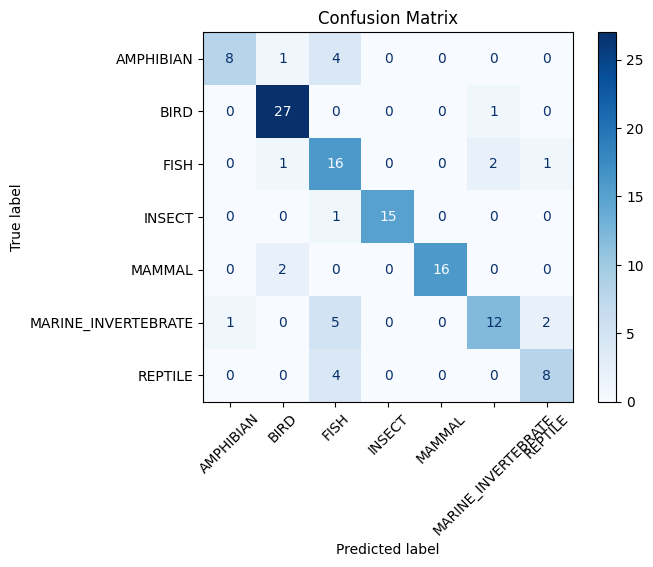

In [ ]:
# ======================
# IMPROVED CNN PIPELINE: MobileNetV2 with Augmentation, Class Weights, Early Stopping
# ======================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import os
import matplotlib.pyplot as plt

# ----------------------
# CONFIGURATION
# ----------------------
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = "/content/drive/MyDrive/Lab19"

# ----------------------
# LOAD DATA
# ----------------------
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "Training"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "Testing"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = full_train_ds.class_names
num_classes = len(class_names)
print(f"✅ Classes detected: {class_names}")

# ----------------------
# TRAIN / VALIDATION SPLIT (80/20)
# ----------------------
train_size = int(0.8 * len(full_train_ds))
train_ds = full_train_ds.take(train_size)
val_ds = full_train_ds.skip(train_size)

# ----------------------
# ENHANCED DATA AUGMENTATION
# ----------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.2, 0.2),
])

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (train_ds
            .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .shuffle(1000)
            .cache()
            .prefetch(AUTOTUNE))

val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# ----------------------
# COMPUTE CLASS WEIGHTS
# ----------------------
y_train = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("✅ Class weights:", class_weights_dict)

# ----------------------
# BASE MODEL: MobileNetV2
# ----------------------
base_model = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False

# ----------------------
# MODEL BUILD
# ----------------------
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

# ----------------------
# CALLBACKS: Early Stopping & Reduce LR
# ----------------------
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# ----------------------
# INITIAL TRAINING (BASE MODEL FROZEN)
# ----------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# ----------------------
# FINE-TUNING (UNFREEZE LAST 50 LAYERS)
# ----------------------
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# ----------------------
# EVALUATION
# ----------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ----------------------
# CLASSIFICATION REPORT
# ----------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# ----------------------
# CONFUSION MATRIX
# ----------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)


disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
!pip install --upgrade tensorflow

Found 444 files belonging to 7 classes.
Found 127 files belonging to 7 classes.
✅ Classes detected: ['AMPHIBIAN', 'BIRD', 'FISH', 'INSECT', 'MAMMAL', 'MARINE_INVERTEBRATE', 'REPTILE']


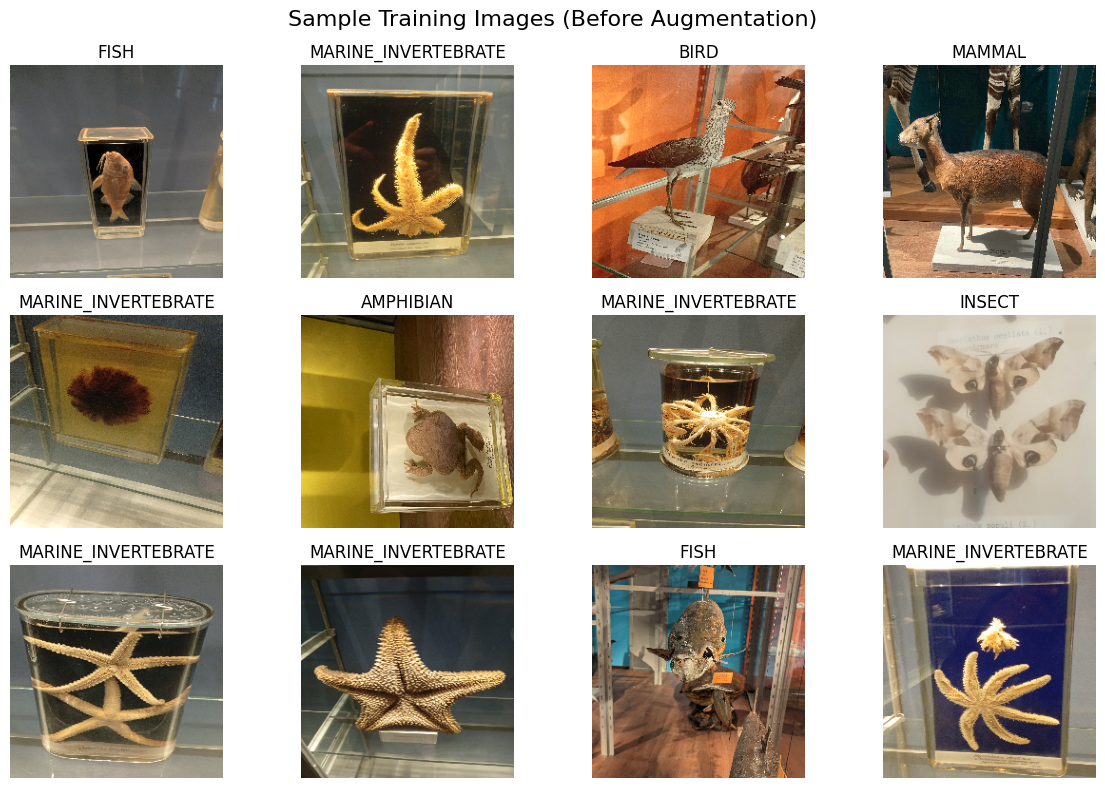

✅ Class weights: {0: np.float64(1.5714285714285714), 1: np.float64(0.6446886446886447), 2: np.float64(0.8380952380952381), 3: np.float64(1.1972789115646258), 4: np.float64(1.2571428571428571), 5: np.float64(0.6984126984126984), 6: np.float64(1.7959183673469388)}
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 84s 7s/step - accuracy: 0.3602 - loss: 2.1863 - val_accuracy: 0.6848 - val_loss: 1.1559 - learning_rate: 0.0010
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8777 - loss: 0.8475 - val_accuracy: 0.8261 - val_loss: 0.9170 - learning_rate: 0.0010
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.9699 - loss: 0.7401 - val_accuracy: 0.8587 - val_loss: 0.8143 - learning_rate: 0.0010
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9791 - loss: 0.6953 - val_accuracy: 0.8913 - val_loss: 0.8124 - learning_rate: 0.0010
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9852 - loss: 0.6753 - val_accuracy: 0.8696 - val_loss: 0.8362 - learning_

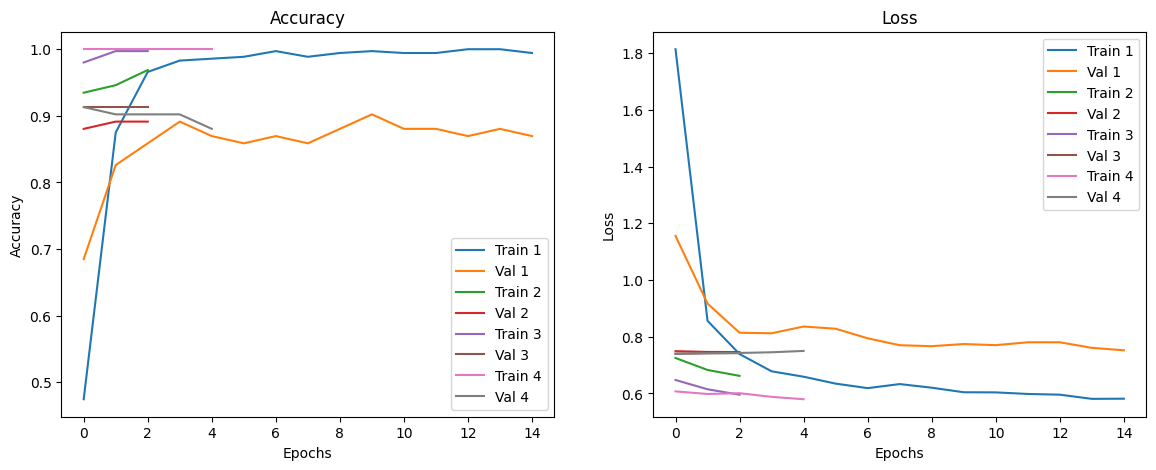

4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.8484 - loss: 0.9169

✅ Test Accuracy: 0.8346
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step

Classification Report:
                     precision    recall  f1-score   support

          AMPHIBIAN       0.83      0.77      0.80        13
               BIRD       0.96      0.96      0.96        28
               FISH       0.59      0.80      0.68        20
             INSECT       1.00      0.94      0.97        16
             MAMMAL       1.00      0.83      0.91        18
MARINE_INVERTEBRATE       0.93      0.65      0.76        20
            REPTILE       0.62      0.83      0.71        12

           accuracy                           0.83       127
          macro avg       0.85      0.83      0.83       127
       weighted avg       0.86      0.83      0.84       127



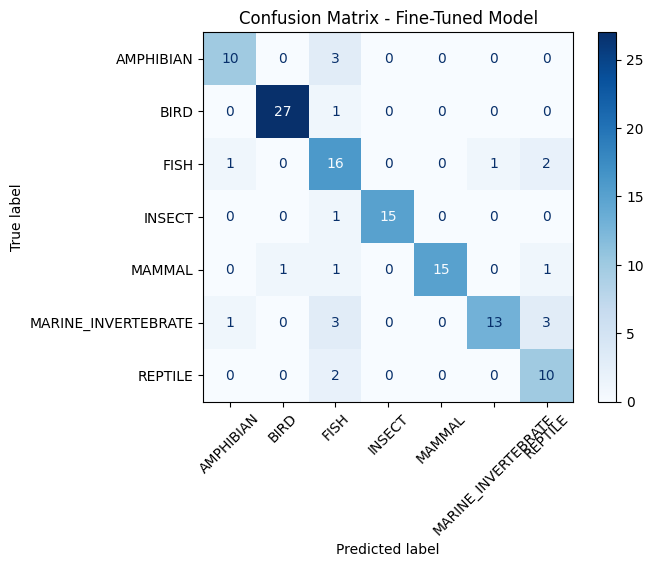

In [ ]:
#v11
# ======================
# IMPROVED CNN PIPELINE WITH VISUALIZATION, AUGMENTATION, REGULARIZATION, FINE-TUNING, AND PLOTS
# ======================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import class_weight
import numpy as np
import os

# ----------------------
# CONFIGURATION
# ----------------------
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = "/content/drive/MyDrive/Lab19"

# ----------------------
# LOAD DATA
# ----------------------
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "Training"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "Testing"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = full_train_ds.class_names
num_classes = len(class_names)
print(f"✅ Classes detected: {class_names}")

# ----------------------
# VISUALIZE SOME TRAINING IMAGES (BEFORE AUGMENTATION)
# ----------------------
def visualize_sample_images(dataset, class_names, num_images=12):
    plt.figure(figsize=(12, 8))
    images_shown = 0
    for images, labels in dataset.take(1):  # take one batch
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 4, images_shown + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
            images_shown += 1
            if images_shown >= num_images:
                break
    plt.suptitle("Sample Training Images (Before Augmentation)", fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_sample_images(full_train_ds, class_names, num_images=12)

# ----------------------
# TRAIN / VALIDATION SPLIT
# ----------------------
train_size = int(0.8 * len(full_train_ds))
train_ds = full_train_ds.take(train_size)
val_ds = full_train_ds.skip(train_size)

# ----------------------
# DATA PIPELINE WITH MODERATE AUGMENTATION
# ----------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (train_ds
            .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .shuffle(1000)
            .cache()
            .prefetch(AUTOTUNE))

val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# ----------------------
# CONVERT LABELS TO ONE-HOT (for label smoothing)
# ----------------------
def one_hot_labels(image, label):
    label = tf.one_hot(label, depth=num_classes)
    return image, label

train_ds = train_ds.map(one_hot_labels)
val_ds = val_ds.map(one_hot_labels)
test_ds = test_ds.map(one_hot_labels)

# ----------------------
# COMPUTE CLASS WEIGHTS
# ----------------------
y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
class_weights = class_weight.compute_class_weight('balanced', classes=np.arange(num_classes), y=np.argmax(y_train, axis=1))
class_weights_dict = dict(enumerate(class_weights))
print("✅ Class weights:", class_weights_dict)

# ----------------------
# BASE MODEL (TRANSFER LEARNING)
# ----------------------
base_model = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False

# ----------------------
# MODEL BUILD WITH DROPOUT + L2
# ----------------------
model_input = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(model_input, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs=model_input, outputs=output)

# ----------------------
# CALLBACKS
# ----------------------
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# ----------------------
# OPTIMIZER
# ----------------------
optimizer = Adam(learning_rate=0.001)

# ----------------------
# INITIAL TRAINING (BASE MODEL FROZEN)
# ----------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# ----------------------
# FINE-TUNING (GRADUAL UNFREEZING)
# ----------------------
def fine_tune(base_model, train_ds, val_ds, class_weights_dict, layers_to_unfreeze, lr, epochs):
    # Unfreeze last `layers_to_unfreeze` layers
    base_model.trainable = True
    for layer in base_model.layers[:-layers_to_unfreeze]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping, reduce_lr],
        class_weight=class_weights_dict
    )
    return history_ft

# Stage 1: last 30 layers, lr=1e-5
history_finetune_1 = fine_tune(base_model, train_ds, val_ds, class_weights_dict, layers_to_unfreeze=30, lr=1e-5, epochs=3)
# Stage 2: last 80 layers, lr=5e-5
history_finetune_2 = fine_tune(base_model, train_ds, val_ds, class_weights_dict, layers_to_unfreeze=80, lr=5e-5, epochs=3)
# Stage 3: unfreeze all, lr=2e-5
history_finetune_3 = fine_tune(base_model, train_ds, val_ds, class_weights_dict, layers_to_unfreeze=len(base_model.layers), lr=2e-5, epochs=5)

# ----------------------
# PLOTS
# ----------------------
def plot_combined_history(*histories):
    plt.figure(figsize=(14, 5))
    # Accuracy
    plt.subplot(1, 2, 1)
    for i, h in enumerate(histories):
        plt.plot(h.history['accuracy'], label=f'Train {i+1}')
        plt.plot(h.history.get('val_accuracy', []), label=f'Val {i+1}')
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    for i, h in enumerate(histories):
        plt.plot(h.history['loss'], label=f'Train {i+1}')
        plt.plot(h.history.get('val_loss', []), label=f'Val {i+1}')
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_combined_history(history, history_finetune_1, history_finetune_2, history_finetune_3)

# ----------------------
# EVALUATION
# ----------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# ----------------------
# PREDICTIONS
# ----------------------
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ----------------------
# CLASSIFICATION REPORT
# ----------------------
labels = list(range(num_classes))
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# ----------------------
# CONFUSION MATRIX
# ----------------------
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Fine-Tuned Model")
plt.show()


In [ ]:
# Save as a Keras HDF5 file
model.save("/content/drive/MyDrive/dataset/model_v12.h5")
print("✅ Saved model to H5 format.")


✅ Saved model to H5 format.


Found 444 files belonging to 7 classes.
Found 127 files belonging to 7 classes.
✅ Classes detected: ['AMPHIBIAN', 'BIRD', 'FISH', 'INSECT', 'MAMMAL', 'MARINE_INVERTEBRATE', 'REPTILE']
✅ Class weights: {0: np.float64(1.5714285714285714), 1: np.float64(0.5915966386554622), 2: np.float64(0.7857142857142857), 3: np.float64(1.2571428571428571), 4: np.float64(1.3968253968253967), 5: np.float64(0.7857142857142857), 6: np.float64(1.6221198156682028)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 101s 8s/step - accuracy: 0.2334 - loss: 2.3558 - val_accuracy: 0.5761 - val_loss: 1.3082 - learning_rate: 0.0010
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5078 - loss: 1.5146 - val_accuracy: 0.7174 - val_loss: 0.9642 - learning_rate: 0.0010
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7146 - loss: 0.9263 - val_accuracy: 0.7935 - val_loss: 0.6973 - learning_rate: 0.0010
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step 

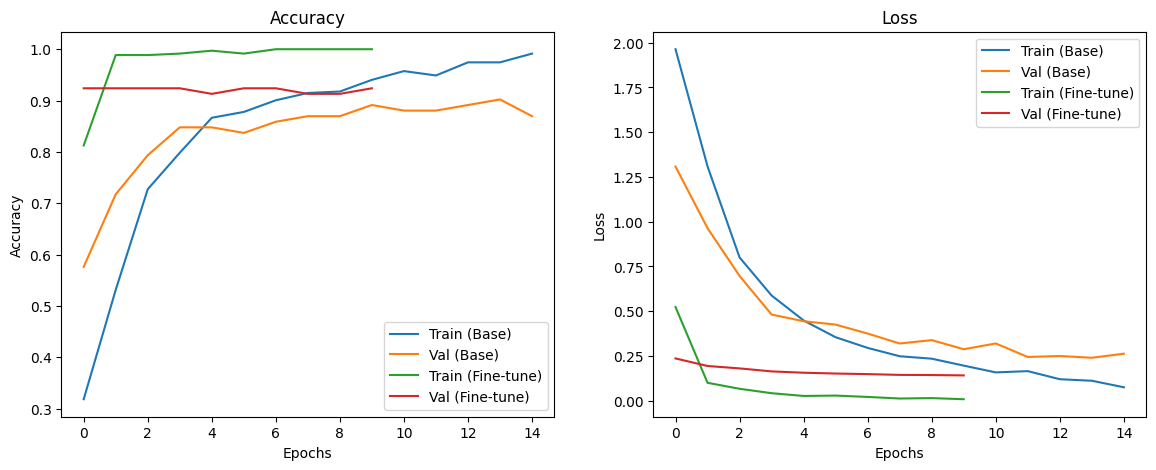

4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 12s/step - accuracy: 0.8861 - loss: 0.3958

✅ Test Accuracy: 0.8898
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report:
                     precision    recall  f1-score   support

          AMPHIBIAN       1.00      0.77      0.87        13
               BIRD       1.00      1.00      1.00        28
               FISH       0.76      0.80      0.78        20
             INSECT       1.00      1.00      1.00        16
             MAMMAL       1.00      0.94      0.97        18
MARINE_INVERTEBRATE       0.89      0.80      0.84        20
            REPTILE       0.59      0.83      0.69        12

           accuracy                           0.89       127
          macro avg       0.89      0.88      0.88       127
       weighted avg       0.91      0.89      0.89       127



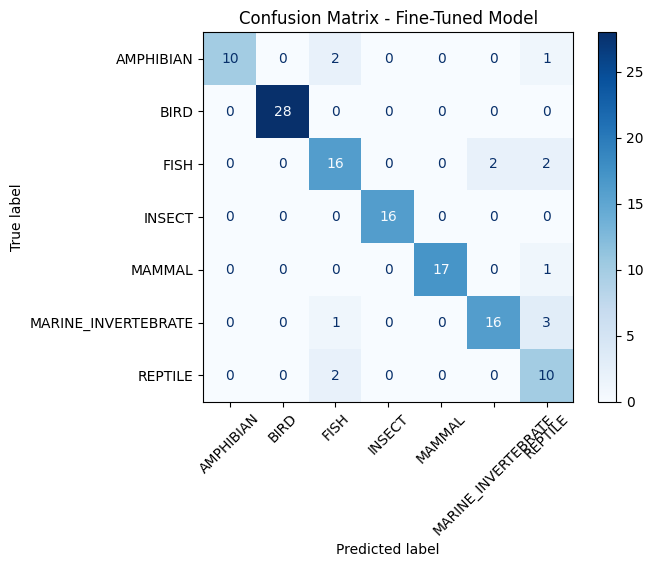

In [ ]:
#V12
# ======================
# IMPROVED CNN PIPELINE WITH MODERATE AUGMENTATION, FINE-TUNING LR, CLASS WEIGHTS, DROPOUT, AND PLOTS
# ======================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import class_weight
import os

# ----------------------
# CONFIGURATION
# ----------------------
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = "/content/drive/MyDrive/Lab19"

# ----------------------
# LOAD DATA
# ----------------------
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "Training"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "Testing"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = full_train_ds.class_names
num_classes = len(class_names)
print(f"✅ Classes detected: {class_names}")

# ----------------------
# TRAIN / VALIDATION SPLIT
# ----------------------
train_size = int(0.8 * len(full_train_ds))
train_ds = full_train_ds.take(train_size)
val_ds = full_train_ds.skip(train_size)

# ----------------------
# DATA PIPELINE WITH MODERATE AUGMENTATION
# ----------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),  # moderate rotation
    layers.RandomZoom(0.1),      # moderate zoom
    layers.RandomContrast(0.1),  # mild contrast
])

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (train_ds
            .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .shuffle(1000)
            .cache()
            .prefetch(AUTOTUNE))

val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# ----------------------
# COMPUTE CLASS WEIGHTS
# ----------------------
y_train = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("✅ Class weights:", class_weights_dict)

# ----------------------
# BASE MODEL (TRANSFER LEARNING)
# ----------------------
base_model = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False

# ----------------------
# MODEL BUILD WITH HIGH DROPOUT
# ----------------------
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # High dropout to reduce overfitting
    layers.Dense(num_classes, activation='softmax')
])

# ----------------------
# CALLBACKS
# ----------------------
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# ----------------------
# INITIAL TRAINING (BASE MODEL FROZEN)
# ----------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# ----------------------
# FINE-TUNING (UNFREEZE LAST 50 LAYERS)
# ----------------------
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # slightly higher LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# ----------------------
# COMBINED TRAINING PLOTS
# ----------------------
def plot_combined_history(h1, h2):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(h1.history['accuracy'], label='Train (Base)')
    plt.plot(h1.history.get('val_accuracy', []), label='Val (Base)')
    plt.plot(h2.history['accuracy'], label='Train (Fine-tune)')
    plt.plot(h2.history.get('val_accuracy', []), label='Val (Fine-tune)')
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(h1.history['loss'], label='Train (Base)')
    plt.plot(h1.history.get('val_loss', []), label='Val (Base)')
    plt.plot(h2.history['loss'], label='Train (Fine-tune)')
    plt.plot(h2.history.get('val_loss', []), label='Val (Fine-tune)')
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_combined_history(history, history_finetune)

# ----------------------
# EVALUATION
# ----------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# ----------------------
# PREDICTIONS
# ----------------------
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ----------------------
# CLASSIFICATION REPORT
# ----------------------
labels = list(range(num_classes))
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# ----------------------
# CONFUSION MATRIX
# ----------------------
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Fine-Tuned Model")
plt.show()


In [ ]:
import tensorflow as tf

# Path to your trained .h5 model
h5_model_path = "/content/drive/MyDrive/dataset/model_v11.h5"

# Output path for .tflite file
tflite_model_path = "/content/drive/MyDrive/Models/model_v3.tflite"

# Load the Keras model
model = tf.keras.models.load_model(h5_model_path)
print("✅ Loaded .h5 model successfully")

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional: optimization for smaller/faster model
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()
print("✅ Conversion successful")

# Save the TFLite model
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ TFLite model saved at: {tflite_model_path}")


✅ Loaded .h5 model successfully
Saved artifact at '/tmp/tmphut_9ykq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_8')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132470819503184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819502032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819502224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819502608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819503952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819502992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819488592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819503760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819503376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132470819500688: TensorSpec(shape=(), dtype=tf.reso